#Diksha Maharjan
##2408235

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Task 1: Data Understanding and Visualization:
Download the Provided Data and Complete the following task.

1. Load and visualize images from a dataset stored in directories, where each subdirec-
tory represents a class. You are expected to write a code:

- Get the list of class directories from the train folder.
- Select one image randomly from each class.
- Display the images in a grid format with two rows using matplotlib.

Detected classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


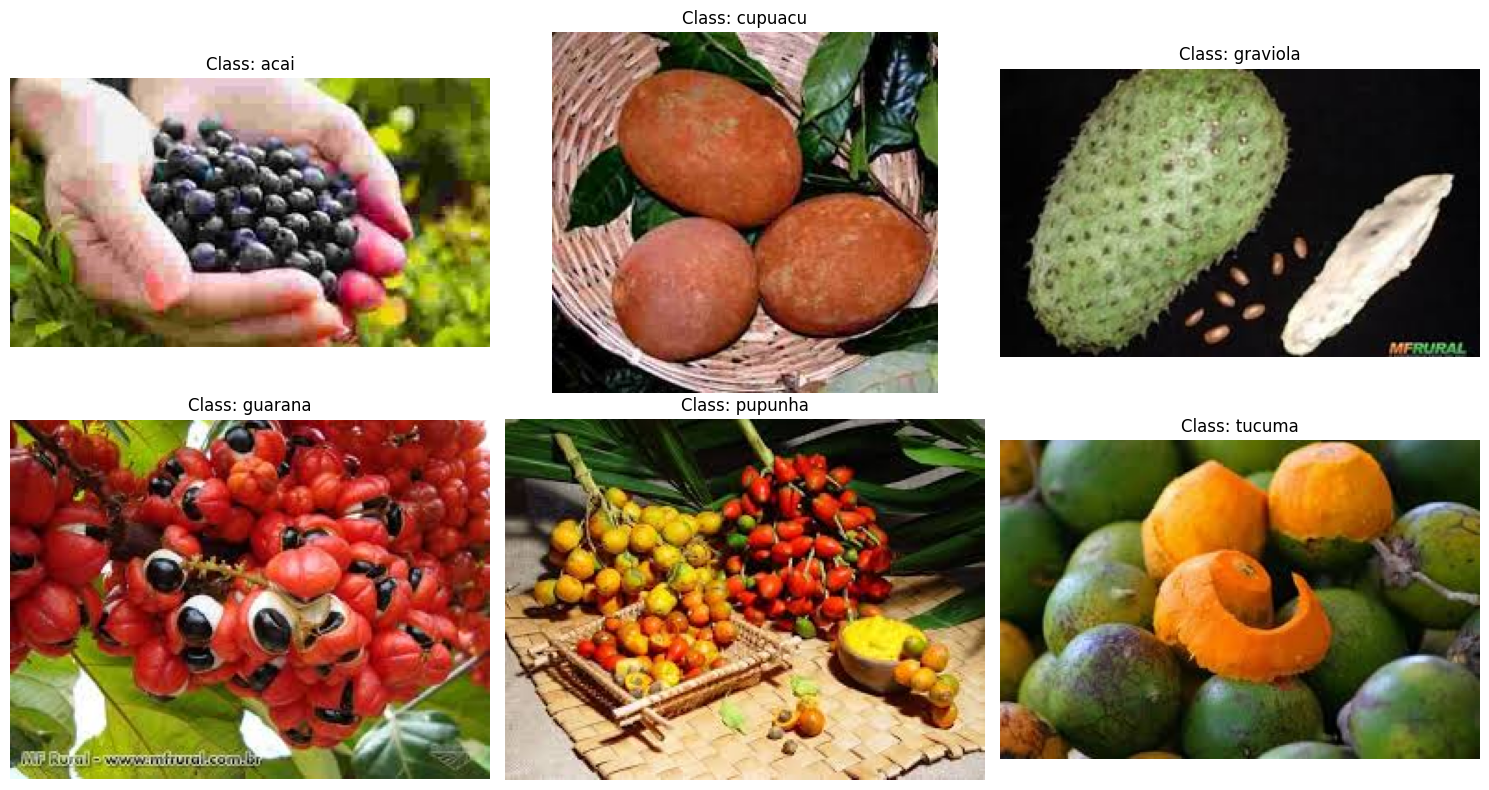

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

#Defining path to training data
train_dir = '/content/drive/MyDrive/sem6/week5/FruitinAmazon/train'

# Get the list of class directories
classes = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
classes.sort() #to keep the order consistent

print(f"Detected classes: {classes}")

# Set up the visualization grid (two rows)
num_classes = len(classes)
cols = (num_classes + 1) //2 #Ceiling division to ensure all classes fit

plt.figure(figsize=(15, 8))
for i, class_name in enumerate(classes):
  class_path = os.path.join(train_dir, class_name)

  #Get all images in this class folder
  images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

  if images:
    #Select one image randomly
    random_img_name = random.choice(images)
    img_path = os.path.join(class_path, random_img_name)

    #load and plot
    img = mpimg.imread(img_path)

    plt.subplot(2, cols, i+1)
    plt.imshow(img)
    plt.title(f"Class: {class_name}")
    plt.axis('off')
plt.tight_layout()
plt.show()


6 images have been displayed randomly from the dataset provided

2. Check for Corrupted Image: Write a script that verifies whether the image in the train
directory are valid. If any corrupted images are found, the script must remove the image from
the directory and print the message which image have been removed, if none found print ”No
Corrupted Images Found.”
• Hint:
– Iterate through each class subdirectory and check if each image is valid.
– Use the Image.open() function to attempt to load each image.
– If the image is corrupted i.e. raises an IOError or SyntaxError, remove the image from
the directory and print f"Removed corrupted image: {image_path}".
– Maintain a list of all corrupted image paths for reporting.
• Expected Output: No corrupted images found.

In [ ]:
from PIL import Image

#List to keep track of removed files
corrupted_images = []

for class_name in classes:
  class_path = os.path.join(train_dir, class_name)
  #Skip directories, check only fi\les
  for filename in os.listdir(class_path):
    image_path = os.path.join(class_path, filename)

    if os.path.isfile(image_path):
      try:
        #Attempt to open and verify the image
        with Image.open(image_path) as img:
          img.verify() #verify image content without loading the whole file
      except (IOError, SyntaxError) as e:
        #if error is raised, file is likely corrupted
        os.remove(image_path)
        corrupted_images.append(image_path)
        print(f"Removed corrupt image: {image_path}")
#final Reporting
if not corrupted_images:
  print("No corrupt images found")
else:
  print(f"Total number of removed images: {len(corrupted_images)}")

No corrupt images found


##Task 2: loading and pre processing data via keras

In [ ]:
import tensorflow as tf

# Define image size and batch size

img_height = 128 # Example image height
img_width = 128 # Example image width
batch_size = 16
validation_split = 0.2 # 80% training, 20% validation

# Create a preprocessing layer for normalization

rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]

# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  labels='inferred',
  label_mode='int',
  image_size=(img_height, img_width),
  interpolation='nearest',
  batch_size=batch_size,
  shuffle=True,
  validation_split=validation_split,
  subset='training',
  seed=123
)

# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  labels='inferred',
  label_mode='int',
  image_size=(img_height, img_width),
  interpolation='nearest',
  batch_size=batch_size,
  shuffle=False,
  validation_split=validation_split,
  subset='validation',
  seed=123
)
# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


Task 3 - Implement a CNN with
Follow the following Structure and Hyper - parameters:
Convolutional Architecture:
• Convolutional Layer 1:
– Filter Size (F): (3, 3)
– Number of Filters (k): 32
– Padding (P): same
– Stride (s): 1
• Activation Layer: ReLU activation
• Pooling Layer 1: Max pooling
– Filter Size (F): (2, 2)
– Stride (s): 2
• Convolutional Layer 2:
– Filter Size (F): (3, 3)
– Number of Filters (k): 32
– Padding (P): same
– Stride (s): 1
• Activation Layer: ReLU activation
• Pooling Layer 2: Max pooling
– Filter Size (F): (2, 2)
– Stride (s): 2

In [ ]:
from tensorflow.keras import layers, models

#Initialize the Sequential model
model = models.Sequential()

# Convolutional Layer 1
# Input shape should match height weight channels from Task 2
model.add(layers.Conv2D(filters=32,
                        kernel_size = (3, 3),
                        padding = 'same',
                        strides = (1, 1),
                        input_shape = (128, 128, 3)
                        ))
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

#Convolutional Layer 2
model.add(layers.Conv2D(filters=32,
                        kernel_size = (3, 3),
                        padding = 'same',
                        strides = (1, 1)
                        ))
model.add(layers.Activation('relu'))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

#Check the architecture summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_32 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,144 (39.62 KB)

 Trainable params: 10,144 (39.62 KB)

 Non-trainable params: 0 (0.00 B)

Fully Connected Network Architecture:
• Flatten Layer: Flatten the input coming from the convolutional layers
• Input Layer:
• Hidden Layer - 2:
– Number of Neurons: 64
– Number of Neurons: 128
• Output Layer:
– Number of Neurons: num classes (number of output classes)

In [ ]:
# #Translate to classification
# model.add(layers.Flatten())

# #Hidden Layer 1 (64 neurons)
# #Note: based on your list, we'll follow the sequence 64 -> 128
# model.add(layers.Dense(64))
# model.add(layers.Activation('relu'))

# # Hidden layers 2 (128 neurons)
# model.add(layers.Dense(128))
# model.add(layers.Activation('relu'))

# #Output layer
# #num_classes is 6 for acai, capuacu, graviola, guarana, pupunha, tocuma
# num_classes = 6
# model.add(layers.Dense(num_classes))
# model.add(layers.Activation('softmax')) #Softma for multi-class probability

# #View the final architecture
# model.summary()
model.add(layers.Flatten())

# Add Dropout after the first Dense layer
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.5)) # Randomly shuts off 50% of neurons during training

# You might not even need this second 128 layer for 6 fruits,
# but if you keep it, add more dropout!
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.3))

model.add(layers.Dense(num_classes, activation='softmax'))
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_31 (Activation)      │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_32 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 4: Compile the Model
Model Compilation
• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).
Task 4: Train the Model
Model Training
• Use the model.fit() function to train the model. Set the batch size to 16 and the number of epochs
to 250.
• Use val ds for validation.

• Use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoid-
ing overfitting.

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

# Compiling the model with the requested parameters -1
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

print("Model compiled successfully.")

# Define the Callbacks - 2
# EarlyStopping: Prevents the model from training for 250 epochs if it stops improving
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# ModelCheckpoint: Saves the 'gold medal' version of your model
checkpoint = ModelCheckpoint(
    'best_fruit_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Execute Training
# Your train_ds already contains the batch_size (16) and shuffling logic
epochs = 250

print("Starting training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stopping, checkpoint],
    shuffle=True
)


Model compiled successfully.
Starting training...
Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.1250 - loss: 2.1573
Epoch 1: val_accuracy improved from None to 0.16667, saving model to best_fruit_model.keras

Epoch 1: finished saving model to best_fruit_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 425ms/step - accuracy: 0.1667 - loss: 2.1624 - val_accuracy: 0.1667 - val_loss: 1.7471
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.2431 - loss: 1.7796
Epoch 2: val_accuracy did not improve from 0.16667
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 353ms/step - accuracy: 0.2361 - loss: 1.7865 - val_accuracy: 0.0000e+00 - val_loss: 1.8860
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.1510 - loss: 1.7649
Epoch 3: val_accuracy did not improve from 0.16667
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 285ms/step - accuracy: 0.2083 - loss: 1.7375 - val_accuracy: 0.0000e+00 - val_loss: 1.8410
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.2573 - loss: 1.7558
Epoch

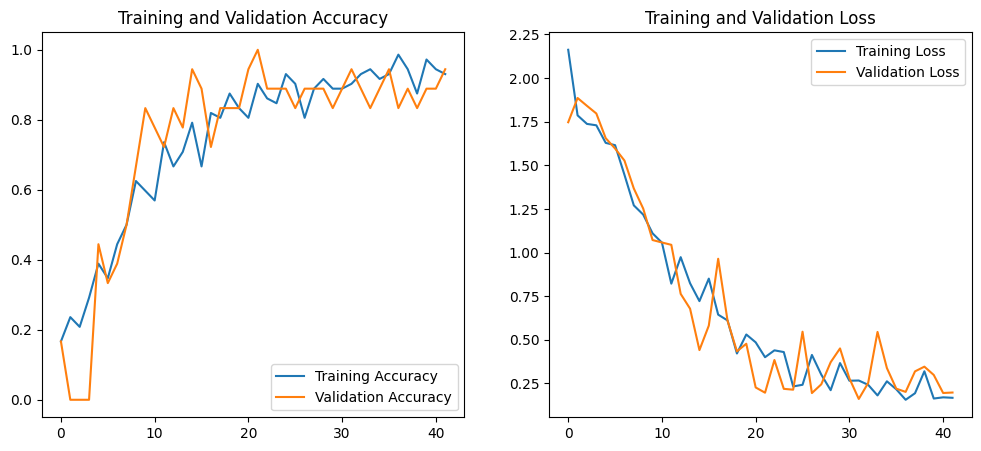

In [ ]:

# Visualize Training Results (Optional but helpful for Task 5)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend(loc='upper right')

plt.show()

Task 5: Evaluate the Model
Model Evaluation
• After training, evaluate the model using model.evaluate() on the test set to check the test accuracy and loss.
Task 6: Save and Load the


In [ ]:
# Task 5: Evaluate the Model

print("Evaluating the model on the test set...")

# 1. Run the evaluation
# This returns the loss value & metrics values for the model in test mode.
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

print("-" * 30)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print("-" * 30)

# Optional: Final check on the saved file
from tensorflow.keras.models import load_model
saved_model = load_model('best_fruit_model.keras')
saved_loss, saved_acc = saved_model.evaluate(test_ds)

Evaluating the model on the test set...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.7000 - loss: 0.8315
------------------------------
Test Loss:     0.8315
Test Accuracy: 0.7000
------------------------------
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 129ms/step - accuracy: 0.6667 - loss: 0.9283


Task 6: Save and Load the Model
Model Saving and Loading
• Save the trained model to an .h5 file using model.save().
• Load the saved model and re-evaluate its performance on the test set.


In [ ]:
import tensorflow as tf

# Define path to the test folder
test_dir = '/content/drive/MyDrive/sem6/week5/FruitinAmazon/test'

# Create the test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(128, 128), # Must match training size
    interpolation='nearest',
    batch_size=16,         # Matching your requested training batch size
    shuffle=False          # No need to shuffle for testing
)

# Normalize the test images (Crucial step!)
normalization_layer = tf.keras.layers.Rescaling(1./255)
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

Found 30 files belonging to 6 classes.


In [ ]:
import tensorflow as tf


# 1. Save the model to an .h5 file
model_filename = 'fruit_classifier_model.h5'
model.save(model_filename)
print(f"Model saved successfully to {model_filename}")

# 2. Load the saved model
# This creates a new 'loaded_model' object independent of the original 'model'
loaded_model = tf.keras.models.load_model(model_filename)
print("Model loaded successfully.")

# 3. Re-evaluate on the test set
# We use the test_ds we created in Task 5
print("\n--- Re-evaluating Loaded Model ---")
loss, accuracy = loaded_model.evaluate(test_ds)

print(f"Loaded Model Test Accuracy: {accuracy * 100:.2f}%")

Model saved successfully to fruit_classifier_model.h5


Model loaded successfully.

--- Re-evaluating Loaded Model ---
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.7000 - loss: 0.8315
Loaded Model Test Accuracy: 70.00%


Task 7: Predictions and Classification Report
Making Predictions
• Use model.predict() to make predictions on test images.
• Convert the model’s predicted probabilities to digit labels using np.argmax().
• Also use from sklearn.metrics import classification report to report the Classification Report of your Model Performance.



CLASSIFICATION REPORT
              precision    recall  f1-score   support

        acai       0.56      1.00      0.71         5
     cupuacu       0.67      0.80      0.73         5
    graviola       1.00      0.80      0.89         5
     guarana       1.00      0.40      0.57         5
     pupunha       0.71      1.00      0.83         5
      tucuma       0.50      0.20      0.29         5

    accuracy                           0.70        30
   macro avg       0.74      0.70      0.67        30
weighted avg       0.74      0.70      0.67        30


CONFUSION MATRIX
[[5 0 0 0 0 0]
 [0 4 0 0 0 1]
 [1 0 4 0 0 0]
 [2 0 0 2 1 0]
 [0 0 0 0 5 0]
 [1 2 0 0 1 1]]


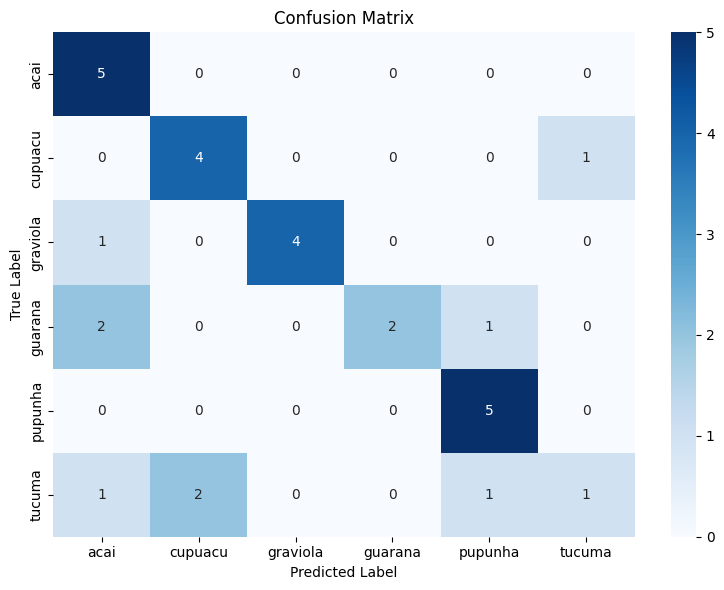

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get the true labels and images from the test set
y_true = []
y_pred = []

# Loop through the test dataset to get predictions
for images, labels in test_ds:
    # Make predictions
    preds = loaded_model.predict(images, verbose=0)  # verbose=0 for cleaner output

    # Convert probabilities to digit labels
    pred_labels = np.argmax(preds, axis=1)

    # Store results
    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)

# Generate classification report
# The original image_dataset_from_directory has class_names, but after .map() it becomes a _MapDataset
# The `classes` variable is already available in the kernel from a previous cell.
class_names = classes

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, target_names=class_names))

# Optional: Confusion Matrix for better visualization
print("\n" + "="*50)
print("CONFUSION MATRIX")
print("="*50)
cm = confusion_matrix(y_true, y_pred)
print(cm)

# Optional: Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()